In [898]:
import random
from typing import List, Dict, Tuple, Optional
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


COLOR_PALETTE = [
    # Pastel colors
    '#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8',
    '#F7DC6F', '#BB8FCE', '#85C1E2', '#F8B88B', '#A8E6CF',

    # Vivid colors
    '#FF5733', '#33FF57', '#3357FF', '#FF33F5', '#F5FF33',
    '#33FFF5', '#F533FF', '#57FF33', '#5733FF', '#FF3357',

    # Warm tones
    '#FF9999', '#FFCC99', '#FFFF99', '#CCFF99', '#99FF99',
    '#99FFCC', '#99FFFF', '#99CCFF', '#9999FF', '#CC99FF',

    # Cool tones
    '#99CCCC', '#6699CC', '#336699', '#003366', '#006666',
    '#009999', '#00CCCC', '#66CCCC', '#99CCFF', '#CCFFFF',

    # Earth tones
    '#D2691E', '#CD853F', '#DEB887', '#F4A460', '#DAA520',
    '#B8860B', '#BC8F8F', '#CD5C5C', '#F08080', '#FA8072',

    # Neon colors
    '#39FF14', '#DFFF00', '#FFFF00', '#FF6600', '#FF00FF',
    '#00FFFF', '#FF007F', '#7FFF00', '#00FF7F', '#FF1493'
]


def visualize_fer_decomposition(
    grid: np.ndarray,
    result: Dict,
    save_path: Optional[str] = None,
    show: bool = True
):
    rows, cols = grid.shape

    plt.figure(figsize=(7, 7))
    plt.imshow(grid, cmap="gray", origin="upper", extent=[0, cols, rows, 0])

    # Draw rectangles with color palette
    for idx, rect_data in enumerate(result['rectangles']):
        color = COLOR_PALETTE[idx % len(COLOR_PALETTE)]

        plt.gca().add_patch(
            plt.Rectangle(
                (rect_data['min_x'], rect_data['min_y']),
                rect_data['width'],
                rect_data['height'],
                facecolor=color,
                alpha=1,
                edgecolor=color
            )
        )

    plt.axis("off")
    plt.title(f"FER Solution: {len(result['rectangles'])} rectangles")

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)

    if show:
        plt.show()
    else:
        plt.close()


import matplotlib.pyplot as plt
import numpy as np

def visualize_concave_vertices(grid, concave_vertices):
    """
    Visualize concave vertices on a binary grid using Matplotlib.

    Active pixels (1) are shown in white, and background pixels (0) in black.
    Concave vertices are highlighted as red pixels with yellow ID labels.

    Args:
        grid (np.ndarray): 2D binary numpy array (0s and 1s).
        concave_vertices (list): List of tuples (id, x, y, corners).
    """
    rows, cols = grid.shape

    # Create an RGB image (3 channels)
    image = np.zeros((rows, cols, 3), dtype=np.uint8)

    # Set pixel colors according to the binary grid
    for i in range(rows):
        for j in range(cols):
            if grid[i, j] == 1:
                image[i, j] = [255, 255, 255]  # White for object
            else:
                image[i, j] = [0, 0, 0]        # Black for background

    # Prepare plot
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")

    # Mark vertices in red and add text labels
    for idx, x, y, corners, cx, cy in concave_vertices:
        if 0 <= y < rows and 0 <= x < cols:
            image[y, x] = [255, 0, 0]  # Highlight specific vertex pixel in red

        # Add vertex ID label to the plot
        plt.text(
            x,
            y,
            str(idx),
            color="yellow",
            fontsize=10,
            ha="center",
            va="center",
            fontweight="bold"
        )

    plt.imshow(image)
    plt.title("Detected Concave Vertices")
    plt.show()


def visualize_concave_vertices_cord(grid, concave_vertices):
    rows, cols = grid.shape

    image = np.zeros((rows, cols, 3), dtype=np.uint8)

    for i in range(rows):
        for j in range(cols):
            if grid[i, j] == 1:
                image[i, j] = [255, 255, 255]
            else:
                image[i, j] = [0, 0, 0]

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")

    # Súradnice každého bieleho pixelu
    for i in range(rows):
        for j in range(cols):
            if grid[i, j] == 1:
                plt.text(
                    j,
                    i,
                    f"({j},{i})",
                    color="gray",
                    fontsize=7,
                    ha="center",
                    va="center",
                    bbox=dict(
                        boxstyle="square,pad=0.1",
                        facecolor="none",
                        edgecolor="gray",
                        linewidth=0.4
                    )
                )

    # Konkávne vrcholy - ID hore, súradnice dole
    for idx, x, y, corners, cx, cy in concave_vertices:
    # Teraz môžeš voliteľne vykresliť aj geometrický roh (cx, cy)
        plt.plot(cx, cy, "mo", markersize=5)
        if 0 <= y < rows and 0 <= x < cols:
            image[y, x] = [255, 0, 0]

        # ID - horná polovica
        plt.text(
            x,
            y - 0.2,
            str(idx),
            color="yellow",
            fontsize=10,
            ha="center",
            va="center",
            fontweight="bold"
        )

        # Súradnice - dolná polovica
        plt.text(
            x,
            y + 0.2,
            f"({x},{y})",
            color="yellow",
            fontsize=7,
            ha="center",
            va="center",
        )

    plt.imshow(image)
    plt.show()

(array([0, 1]), array([76, 34]))


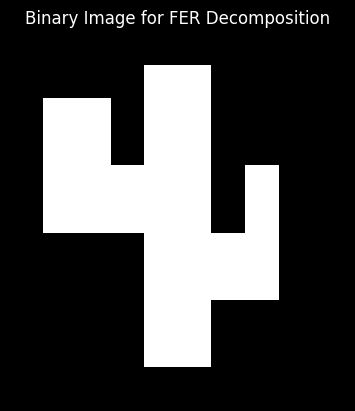

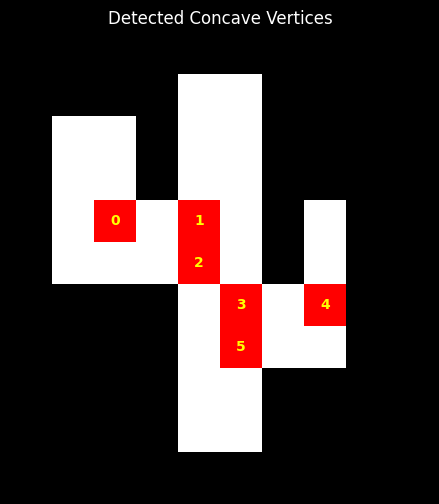

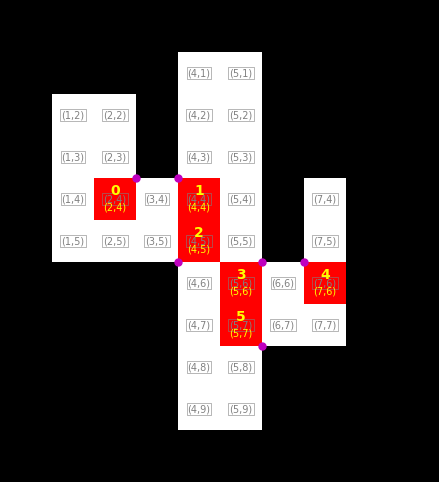

Concave Vertices:  6
0: [2,4] corner: ['top-right'] (geom: 2.5, 3.5)
1: [4,4] corner: ['top-left'] (geom: 3.5, 3.5)
2: [4,5] corner: ['bottom-left'] (geom: 3.5, 5.5)
3: [5,6] corner: ['top-right'] (geom: 5.5, 5.5)
4: [7,6] corner: ['top-left'] (geom: 6.5, 5.5)
5: [5,7] corner: ['bottom-right'] (geom: 5.5, 7.5)
FER ALGORITHM - LEVEL 1 (GREEDY MIS)
Total possible chords: 3
MIS selected: 2 chords
Remaining vertices for Level 2: 2

Level 1 Chords:  2
{'id': 1, 'type': 'vertical', 'v1_id': 1, 'v2_id': 2, 'v1': (4, 4), 'v2': (4, 5), 'x_line': 3.5, 'y_range': (3.5, 5.5), 'interior_side': 'both'}
{'id': 2, 'type': 'vertical', 'v1_id': 3, 'v2_id': 5, 'v1': (5, 6), 'v2': (5, 7), 'x_line': 5.5, 'y_range': (5.5, 7.5), 'interior_side': 'both'}

Level 1 Precise Cuts:
{'type': 'vertical', 'x_line': 3.5, 'y_range': (3.5, 5.5), 'side': 'both'}
{'type': 'vertical', 'x_line': 5.5, 'y_range': (5.5, 7.5), 'side': 'both'}

FER ALGORITHM - LEVEL 2 (NEAREST EDGE)
value=remaining_vertices_count:2

Processing V

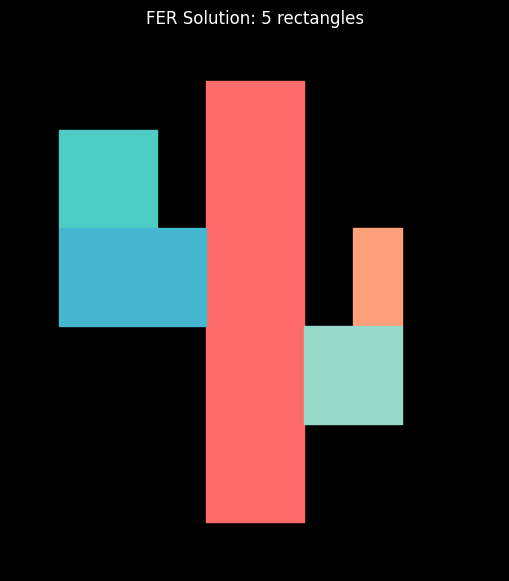

In [899]:
"""Graph-based (FER) algorithm for binary image rectangle decomposition."""

import numpy as np
from collections import defaultdict, deque
import matplotlib.pyplot as plt
from collections import defaultdict
import math


def find_concave_vertices(grid):

    rows, cols = grid.shape
    concave = []

    for y in range(rows - 1):
        for x in range(cols - 1):
            block = grid[y:y+2, x:x+2]
            if block.sum() == 3:
                # Concave corner - corner of block
                concave.append((x, y))

    return concave


def find_concave_corners(grid):
    rows, cols = grid.shape
    concave_points = []
    idx = 0

    for y in range(rows):
        for x in range(cols):
            if grid[y, x] == 1:
                # Pomocná funkcia na čítanie susedov
                def g(dy, dx):
                    ny, nx = y + dy, x + dx
                    if 0 <= ny < rows and 0 <= nx < cols:
                        return grid[ny, nx]
                    return 0

                t, b = g(-1, 0), g(1, 0)
                l, r = g(0, -1), g(0, 1)
                tl, tr = g(-1, -1), g(-1, 1)
                bl, br = g(1, -1), g(1, 1)

                # Kontrola konkávnych rohov a priradenie cx, cy
                # Top-Left konkávny: hore a vľavo je plno, ale diagonálne vľavo hore je prázdno
                if t == 1 and l == 1 and tl == 0:
                    cx, cy = x - 0.5, y - 0.5
                    concave_points.append((idx, x, y, ["top-left"], cx, cy))
                    idx += 1

                if t == 1 and r == 1 and tr == 0:
                    cx, cy = x + 0.5, y - 0.5
                    concave_points.append((idx, x, y, ["top-right"], cx, cy))
                    idx += 1

                if b == 1 and r == 1 and br == 0:
                    cx, cy = x + 0.5, y + 0.5
                    concave_points.append((idx, x, y, ["bottom-right"], cx, cy))
                    idx += 1

                if b == 1 and l == 1 and bl == 0:
                    cx, cy = x - 0.5, y + 0.5
                    concave_points.append((idx, x, y, ["bottom-left"], cx, cy))
                    idx += 1

    return concave_points


def find_cogrid_pairs_old(concave_vertices, grid):
    rows, cols = grid.shape
    chords = []
    chord_id = 0

    # concave_vertices: list of (id, x, y, corners)

    def chord_lies_inside(positions, axis, fixed):
        if axis == "horizontal":
            y = fixed
            return all(grid[y, x] == 1 for x in positions)
        else:
            x = fixed
            return all(grid[y, x] == 1 for y in positions)

    def interior_side_horizontal(corners):
        sides = set()
        for c in corners:
            if "bottom" in c:
                sides.add("above")
            if "top" in c:
                sides.add("below")
        return sides

    def interior_side_vertical(corners):
        sides = set()
        for c in corners:
            if "right" in c:
                sides.add("left")
            if "left" in c:
                sides.add("right")
        return sides

    def has_interior_on_side_horizontal(y, x_min, x_max, side):
        if side == "above":
            if y <= 0:
                return False
            return all(grid[y - 1, x] == 1 for x in range(x_min, x_max + 1))
        else:  # below
            if y >= rows - 1:
                return False
            return all(grid[y + 1, x] == 1 for x in range(x_min, x_max + 1))

    def has_interior_on_side_vertical(x, y_min, y_max, side):
        if side == "left":
            if x <= 0:
                return False
            return all(grid[y, x - 1] == 1 for y in range(y_min, y_max + 1))
        else:  # right
            if x >= cols - 1:
                return False
            return all(grid[y, x + 1] == 1 for y in range(y_min, y_max + 1))

    # --- Horizontálne chordy ---
    y_groups = defaultdict(list)
    for (vid, x, y, corners) in concave_vertices:
        y_groups[y].append((vid, x, y, corners))

    for y, vertices in y_groups.items():
        vertices = sorted(vertices, key=lambda v: v[1])  # sort by x

        for i in range(len(vertices) - 1):
            v1 = vertices[i]
            v2 = vertices[i + 1]
            _, x1, _, corners1 = v1
            _, x2, _, corners2 = v2

            x_min, x_max = min(x1, x2), max(x1, x2)
            if x_max - x_min < 1:
                continue

            # chord musí ležať celý vo vnútri
            if not chord_lies_inside(range(x_min, x_max + 1), "horizontal", y):
                continue

            # oba vrcholy musia mať spoločnú stranu interiéru
            sides1 = interior_side_horizontal(corners1)
            sides2 = interior_side_horizontal(corners2)
            common_sides = sides1 & sides2

            if not common_sides:
                continue

            # overíme že na spoločnej strane je skutočne súvislý interiér
            valid_side = None
            for side in common_sides:
                if has_interior_on_side_horizontal(y, x_min, x_max, side):
                    valid_side = side
                    break

            if valid_side is None:
                continue

            chords.append({
                "id": chord_id,
                "type": "horizontal",
                "v1": (x1, y),
                "v2": (x2, y),
                "v1_id": vertices[i][0],    # vid
                "v2_id": vertices[i+1][0],  # vid
                "y": y,
                "x_range": (x_min, x_max),
                "interior_side": valid_side
            })
            chord_id += 1

    # --- Vertikálne chordy ---
    x_groups = defaultdict(list)
    for (vid, x, y, corners) in concave_vertices:
        x_groups[x].append((vid, x, y, corners))

    for x, vertices in x_groups.items():
        vertices = sorted(vertices, key=lambda v: v[2])  # sort by y

        for i in range(len(vertices) - 1):
            v1 = vertices[i]
            v2 = vertices[i + 1]
            _, _, y1, corners1 = v1
            _, _, y2, corners2 = v2

            y_min, y_max = min(y1, y2), max(y1, y2)
            if y_max - y_min < 1:
                continue

            # chord musí ležať celý vo vnútri
            if not chord_lies_inside(range(y_min, y_max + 1), "vertical", x):
                continue

            # oba vrcholy musia mať spoločnú stranu interiéru
            sides1 = interior_side_vertical(corners1)
            sides2 = interior_side_vertical(corners2)
            common_sides = sides1 & sides2

            if not common_sides:
                continue

            # overíme že na spoločnej strane je skutočne súvislý interiér
            valid_side = None
            for side in common_sides:
                if has_interior_on_side_vertical(x, y_min, y_max, side):
                    valid_side = side
                    break

            if valid_side is None:
                continue

            chords.append({
                "id": chord_id,
                "type": "vertical",
                "v1": (x, y1),
                "v2": (x, y2),
                "v1_id": vertices[i][0],    # vid
                "v2_id": vertices[i+1][0],  # vid
                "x": x,
                "y_range": (y_min, y_max),
                "interior_side": valid_side
            })
            chord_id += 1

    return chords


def find_cogrid_pairs_new(concave_vertices, grid, verbose=False):
    rows, cols = grid.shape
    chords = []
    chord_id = 0

    # 1. Prepare and enrich vertex data
    enriched_vertices = []
    for vid, px, py, corner, cx, cy in concave_vertices:
        ctype = corner[0] if isinstance(corner, list) else corner
        enriched_vertices.append({
            "id": vid, "px": px, "py": py, "corner": ctype,
            "cx": cx, "cy": cy
        })

    # --- HORIZONTAL CHORDS ---
    y_groups = defaultdict(list)
    for v in enriched_vertices:
        y_groups[v["cy"]].append(v)

    for cy, verts in y_groups.items():
        # Sort by X to ensure we only check adjacent vertices (Direct Visibility)
        sorted_verts = sorted(verts, key=lambda v: v["cx"])

        for i in range(len(sorted_verts) - 1):
            v1, v2 = sorted_verts[i], sorted_verts[i+1]

            # Integer range for grid sampling
            x_start = int(min(v1["px"], v2["px"]))
            x_end = int(max(v1["px"], v2["px"]))

            # Check rows immediately above and below the line
            check_y_above = int(cy - 0.5)
            check_y_below = int(cy + 0.5)

            # A path is valid only if it's entirely inside the object (grid == 1)
            # and it's NOT a boundary (meaning it must have interior space)
            path_above = False
            if 0 <= check_y_above < rows:
                path_above = all(grid[check_y_above, x] == 1 for x in range(x_start, x_end))

            path_below = False
            if 0 <= check_y_below < rows:
                path_below = all(grid[check_y_below, x] == 1 for x in range(x_start, x_end))

            # Logic: If both sides are 1, it's a perfect internal cut.
            # If only one side is 1 and the other is 0, it's a boundary edge (invalid for Level 1).
            if path_above and path_below:
                chords.append({
                    "id": chord_id,
                    "type": "horizontal",
                    "v1_id": v1["id"],
                    "v2_id": v2["id"],
                    "v1": (v1["px"], v1["py"]),
                    "v2": (v2["px"], v2["py"]),
                    "y_line": cy,
                    "x_range": (v1["cx"], v2["cx"]),
                    "interior_side": "both" # Optimal FER chord
                })
                chord_id += 1

    # --- VERTICAL CHORDS ---
    x_groups = defaultdict(list)
    for v in enriched_vertices:
        x_groups[v["cx"]].append(v)

    for cx, verts in x_groups.items():
        # Sort by Y to ensure we only check adjacent vertices
        sorted_verts = sorted(verts, key=lambda v: v["cy"])

        for i in range(len(sorted_verts) - 1):
            v1, v2 = sorted_verts[i], sorted_verts[i+1]

            # Integer range for grid sampling
            y_start = int(min(v1["py"], v2["py"]))
            y_end = int(max(v1["py"], v2["py"]))

            # Check columns immediately left and right of the line
            check_x_left = int(cx - 0.5)
            check_x_right = int(cx + 0.5)

            path_left = False
            if 0 <= check_x_left < cols:
                path_left = all(grid[y, check_x_left] == 1 for y in range(y_start, y_end))

            path_right = False
            if 0 <= check_x_right < cols:
                path_right = all(grid[y, check_x_right] == 1 for y in range(y_start, y_end))

            # A vertical chord is valid only if it's internal (both sides are grid == 1)
            if path_left and path_right:
                chords.append({
                    "id": chord_id,
                    "type": "vertical",
                    "v1_id": v1["id"],
                    "v2_id": v2["id"],
                    "v1": (v1["px"], v1["py"]),
                    "v2": (v2["px"], v2["py"]),
                    "x_line": cx,
                    "y_range": (v1["cy"], v2["cy"]),
                    "interior_side": "both"
                })
                chord_id += 1

    return chords


def chords_intersect(c1, c2):
    if c1['type'] == c2['type']:
        return False

    h = c1 if c1['type'] == 'horizontal' else c2
    v = c2 if c1['type'] == 'horizontal' else c1

    h_y = h.get('y_line') if h.get('y_line') is not None else h.get('y')
    v_x = v.get('x_line') if v.get('x_line') is not None else v.get('x')

    h_x_min, h_x_max = h["x_range"]
    v_y_min, v_y_max = v["y_range"]

    # ZMENA: Používame <= a >= namiesto ostrých nerovností
    # Ak sa horizontálna čiara pretína s vertikálnou v ich rozsahu, je to konflikt.
    intersect_x = (h_x_min <= v_x <= h_x_max)
    intersect_y = (v_y_min <= h_y <= v_y_max)

    return intersect_x and intersect_y


def build_conflict_graph(chords, grid):
    # Inicializujeme graf pre každé ID chordu
    graph = {chord['id']: [] for chord in chords}

    for i in range(len(chords)):
        for j in range(i + 1, len(chords)):
            if chords_intersect(chords[i], chords[j]):
                # Pridáme hranu do oboch smerov
                graph[chords[i]['id']].append(chords[j]['id'])
                graph[chords[j]['id']].append(chords[i]['id'])
    return graph

def is_bipartite_graph(chords, graph):
    return True


def maximum_matching_bipartite(chords, graph):
    horizontal = [c for c in chords if c['type'] == 'horizontal']

    # match_v[v_id] = h_id ktorý je spárovaný s týmto V chordom
    match_v = {}

    def dfs(h_id, visited):
        for v_id in graph[h_id]:
            if v_id in visited:
                continue
            visited.add(v_id)
            if v_id not in match_v or dfs(match_v[v_id], visited):
                match_v[v_id] = h_id
                return True
        return False

    for h_chord in horizontal:
        dfs(h_chord['id'], set())

    matched_pairs = set()
    for v_id, h_id in match_v.items():
        matched_pairs.add(tuple(sorted([h_id, v_id])))

    return matched_pairs


def solve_mis_for_chords(chords, conflict_graph):
    """
    Finds the Maximum Independent Set of chords.
    This replaces the bipartite matching because the conflict graph
    contains H-H and V-V conflicts (sharing vertices), not just H-V.
    """
    # 1. Sort nodes by their degree (number of conflicts) - Ascending
    # Nodes with fewer conflicts are "better" candidates to keep.
    nodes = sorted(chords, key=lambda c: len(conflict_graph[c['id']]))

    selected_ids = []
    rejected_ids = set()

    for chord in nodes:
        c_id = chord['id']
        if c_id not in rejected_ids:
            # We take this chord
            selected_ids.append(c_id)
            # All its neighbors in the conflict graph are now forbidden
            for neighbor_id in conflict_graph[c_id]:
                rejected_ids.add(neighbor_id)

    return selected_ids


def is_chord_on_boundary(chord, grid):
    rows, cols = grid.shape

    if chord['type'] == 'horizontal':
        y = chord['y']
        x_min, x_max = chord['x_range']

        above_empty = all(grid[y-1, x] == 0 for x in range(x_min, x_max + 1) if y > 0)
        below_empty = all(grid[y+1, x] == 0 for x in range(x_min, x_max + 1) if y < rows - 1)

        return above_empty or below_empty

    else:  # vertical
        x = chord['x']
        y_min, y_max = chord['y_range']

        left_empty = all(grid[y, x-1] == 0 for y in range(y_min, y_max + 1) if x > 0)
        right_empty = all(grid[y, x+1] == 0 for y in range(y_min, y_max + 1) if x < cols - 1)

        return left_empty or right_empty


def maximum_independent_set(chords, graph, matching_pairs):

    # Množina všetkých chord IDs
    all_chord_ids = {c['id'] for c in chords}

    # Chord IDs, ktoré sú v matchingu
    matched_chord_ids = set()
    for pair in matching_pairs:
        matched_chord_ids.add(pair[0])
        matched_chord_ids.add(pair[1])

    # Izolované vrcholy (bez hran v grafe)
    isolated = set()
    for chord in chords:
        if len(graph[chord['id']]) == 0:
            isolated.add(chord['id'])

    # Vrcholy, ktoré nie sú v matchingu
    unmatched = all_chord_ids - matched_chord_ids

    # MIS: vyberieme jeden z každého páru + izolované + nezávislé unmatched
    mis = set()

    # 1. Izolované vrcholy (vždy ich pridáme - žiadne konflikty)
    mis.update(isolated)

    # 2. Jeden z každého matchovaného páru
    # Deterministicky vyberieme prvý z páru (pár je už sorted tuple)
    for pair in matching_pairs:
        mis.add(pair[0])

    # 3. Unmatched vrcholy, ktoré sú nezávislé od už vybraných
    for chord_id in unmatched:
        # Skontrolujeme, či je nezávislý od všetkých už vybraných
        is_independent = True
        for selected_id in mis:
            if selected_id in graph[chord_id]:
                is_independent = False
                break

        if is_independent:
            mis.add(chord_id)

    return mis


def fer_algorithm_level1(concave_vertices, grid, verbose=False):
    """
    Complete Level 1: Find all possible chords, build conflict graph,
    and select the optimal independent set of chords.
    """
    if verbose:
        print("=" * 70)
        print("FER ALGORITHM - LEVEL 1 (GREEDY MIS)")
        print("=" * 70)

    # 1. Find all possible valid chords between concave vertices
    chords = find_cogrid_pairs_new(concave_vertices, grid)

    if not chords:
        if verbose: print("No Level 1 chords found.")
        return [], concave_vertices

    # 2. Build the conflict graph
    # This must handle crossing (H-V) and shared vertices (H-H, V-V)
    graph = build_conflict_graph(chords, grid)

    # 3. Solve Maximum Independent Set (MIS) using Greedy Heuristic
    # We prioritize chords with the fewest conflicts to maximize the count
    sorted_chords = sorted(chords, key=lambda c: len(graph.get(c['id'], [])))

    selected_chord_ids = []
    forbidden_ids = set()

    for chord in sorted_chords:
        c_id = chord['id']
        if c_id not in forbidden_ids:
            selected_chord_ids.append(c_id)
            # Mark all conflicting chords as forbidden
            for neighbor_id in graph.get(c_id, []):
                forbidden_ids.add(neighbor_id)

    # 4. Final selection and remaining vertices
    level1_chords = [c for c in chords if c['id'] in selected_chord_ids]

    used_v_ids = set()
    for c in level1_chords:
        used_v_ids.add(c['v1_id'])
        used_v_ids.add(c['v2_id'])

    remaining_vertices = [v for v in concave_vertices if v[0] not in used_v_ids]

    if verbose:
        print(f"Total possible chords: {len(chords)}")
        print(f"MIS selected: {len(level1_chords)} chords")
        print(f"Remaining vertices for Level 2: {len(remaining_vertices)}")

    return level1_chords, remaining_vertices


def fer_algorithm_level2(remaining_vertices, grid, level1_chords, verbose=False):
    if verbose:
        print("\n" + "=" * 70)
        print("FER ALGORITHM - LEVEL 2 (NEAREST EDGE)")
        print("=" * 70)
        print(f"value=remaining_vertices_count:{len(remaining_vertices)}")

    level2_chords = []

    def get_allowed_directions(corners):
        directions = set()
        c = corners[0] if isinstance(corners, list) else corners
        if "top" in c: directions.add("down")
        if "bottom" in c: directions.add("up")
        if "left" in c: directions.add("right")
        if "right" in c: directions.add("left")
        return directions

    def is_blocked_by_chord(cx, cy, direction, blocking_chords):
        for chord in blocking_chords:
            c_type = chord.get('type')

            if c_type == 'vertical' and direction in ('left', 'right'):
                c_line = chord.get('x_line') if chord.get('x_line') is not None else chord.get('x')
                c_range = chord.get('y_range')

                # Debug print pre vertikálnu kontrolu
                if verbose:
                    print(f"  [BlockCheck] type=V, beam_x={cx}, beam_y={cy}, chord_line={c_line}")

                if c_line is not None and abs(cx - c_line) < 0.01:
                    if c_range and c_range[0] <= cy <= c_range[1]:
                        if verbose: print(f"    value=BLOCKED_BY_V_CHORD:{c_line}")
                        return True

            elif c_type == 'horizontal' and direction in ('up', 'down'):
                c_line = chord.get('y_line') if chord.get('y_line') is not None else chord.get('y')
                c_range = chord.get('x_range')

                # Debug print pre horizontálnu kontrolu
                if verbose:
                    print(f"  [BlockCheck] type=H, beam_x={cx}, beam_y={cy}, chord_line={c_line}")

                if c_line is not None and abs(cy - c_line) < 0.01:
                    if c_range and c_range[0] <= cx <= c_range[1]:
                        if verbose: print(f"    value=BLOCKED_BY_H_CHORD:{c_line}")
                        return True
        return False

    def extend_chord(v_cx, v_cy, direction, grid, level2_chords, level1_cuts):
        # Spojíme všetky rezy, ktoré môžu lúč zastaviť
        blocking_all = level1_cuts + level2_chords
        curr_cx, curr_cy = v_cx, v_cy
        path = [(curr_cx, curr_cy)]
        rows, cols = grid.shape

        # Poistka proti nekonečnému cyklu (vždy dobrá prax)
        max_steps = (rows + cols) * 2
        steps = 0

        while steps < max_steps:
            steps += 1

            # 1. POHYB (o polovicu pixelovej jednotky)
            if direction == 'right':   curr_cx += 0.5
            elif direction == 'left':  curr_cx -= 0.5
            elif direction == 'down':  curr_cy += 0.5
            elif direction == 'up':    curr_cy -= 0.5

            # 2. KONTROLA GEOMETRICKÝCH HRANÍC MRIEŽKY (0 až cols/rows)
            # Toto okamžite zastaví lúč, ak by mal ísť do záporných čísel (napr. -0.5)
            if curr_cx < 0 or curr_cx > cols or curr_cy < 0 or curr_cy > rows:
                if verbose:
                    print(f"    value=EXTEND_STOP_REASON:hard_boundary_limit:({curr_cx},{curr_cy})")
                return path

            # 3. KONTROLA OBSAHU MRIEŽKY (Prázdne miesta / Nuly)
            # Vykonáva sa len na celočíselných súradniciach (keď lúč vstupuje do pixelu)
            if curr_cx % 1.0 == 0 and curr_cy % 1.0 == 0:
                # Určíme index pixela v poli grid na základe smeru pohybu
                idx_x = int(curr_cx) if direction != 'left' else int(curr_cx - 1)
                idx_y = int(curr_cy) if direction != 'up' else int(curr_cy - 1)

                # Ak je bunka nula (mimo objektu), končíme rez na hrane objektu
                # Podmienka 0 <= idx je tu pre istotu, ak by pohyb nebol presne 0.5
                if (0 <= idx_x < cols and 0 <= idx_y < rows):
                    if grid[idx_y, idx_x] == 0:
                        if verbose:
                            print(f"    value=EXTEND_STOP_REASON:empty_grid_at:({idx_x},{idx_y})")
                        return path
                else:
                    # Ak sme technicky mimo indexov gridu, tiež končíme
                    return path

            # 4. KONTROLA KOLÍZIE S INÝMI REZMI (Blocking Chords)
            # Toto robíme až POTOM, čo vieme, že sme stále vnútri platného objektu
            if is_blocked_by_chord(curr_cx, curr_cy, direction, blocking_all):
                path.append((curr_cx, curr_cy))
                if verbose:
                    print(f"    value=EXTEND_STOP_REASON:chord_collision")
                return path

            # 5. UKLADANIE CESTY
            # Uložíme súradnicu, ak je to stred hrany alebo stred pixela (0.5 polohy)
            if curr_cx % 1.0 == 0.5 or curr_cy % 1.0 == 0.5:
                if (curr_cx, curr_cy) not in path:
                    path.append((curr_cx, curr_cy))

        return path

    def build_chord(vertex, direction, path):
        if len(path) < 2: return None
        idx, px, py, corner, v_cx, v_cy = vertex
        end_cx, end_cy = path[-1]
        ctype = corner[0] if isinstance(corner, list) else corner

        if direction in ('left', 'right'):
            res = {
                'type': 'horizontal', 'v1': (v_cx, v_cy), 'v2': (end_cx, end_cy),
                'y_line': v_cy, 'x_range': (min(v_cx, end_cx), max(v_cx, end_cx)),
                'interior_side': "below" if "top" in ctype else "above",
                'direction': direction, 'v1_id': idx, 'v2_id': None
            }
        else:
            res = {
                'type': 'vertical', 'v1': (v_cx, v_cy), 'v2': (end_cx, end_cy),
                'x_line': v_cx, 'y_range': (min(v_cy, end_cy), max(v_cy, end_cy)),
                'interior_side': "right" if "left" in ctype else "left",
                'direction': direction, 'v1_id': idx, 'v2_id': None
            }
        return res

    for vertex in remaining_vertices:
        idx, x, y, corners, v_cx, v_cy = vertex
        allowed_directions = get_allowed_directions(corners)
        if verbose: print(f"\nProcessing Vertex V{idx} at ({x},{y}), value=allowed_dirs:{allowed_directions}")

        candidates = []
        for direction in allowed_directions:
            if verbose: print(f"  Exploring direction value={direction}...")
            pixels = extend_chord(v_cx, v_cy, direction, grid, level2_chords, level1_chords)
            chord = build_chord(vertex, direction, pixels)
            if chord:
                chord['length'] = len(pixels)
                candidates.append(chord)
                if verbose: print(f"    value=CANDIDATE_FOUND: len={chord['length']}, to={chord['v2']}")

        if candidates:
            selected = min(candidates, key=lambda c: c['length'])
            level2_chords.append(selected)
            if verbose:
                print(f"  value=FINAL_SELECTION:V{idx} dir={selected['direction']} length={selected['length']}")
        else:
            if verbose: print(f"  value=WARNING:V{idx}_no_candidates")

    return level2_chords


def fer_algorithm_level2_sweep(remaining_vertices, grid, level1_cuts, verbose=False, direction='horizontal'):
    """
    Level 2 so sweep line algoritmom.
    direction='horizontal' → sweep zľava doprava (vertikálna sweep line), rezy horizontálne
    direction='vertical'   → sweep zhora nadol (horizontálna sweep line), rezy vertikálne
    """

    if verbose:
        print("\n" + "=" * 70)
        print(f"FER ALGORITHM - LEVEL 2 (SWEEP LINE, sweep={direction})")
        print("=" * 70)
        print(f"Remaining vertices: {len(remaining_vertices)}")

    level2_chords = []
    rows, cols = grid.shape

    # --- Pomocné funkcie (rovnaké ako predtým) ---

    def get_allowed_directions(corners):
        directions = set()
        for corner in corners:
            if "top" in corner: directions.add("up")
            if "bottom" in corner: directions.add("down")
            if "left" in corner: directions.add("left")
            if "right" in corner: directions.add("right")
        return directions

    def is_blocked_by_chord(cx, cy, direction, blocking_chords):
        for chord in blocking_chords:
            c_type = chord['type']

            if c_type == 'vertical' and direction in ('left', 'right'):
                # Skúsime všetky možné kľúče pre x-ovú súradnicu vertikálneho rezu
                c_line = chord.get('x_line')
                if c_line is None: c_line = chord.get('x') # fallback na starý formát

                if c_line is not None and abs(cx - c_line) < 0.01:
                    c_range = chord.get('y_range')
                    if c_range and c_range[0] <= cy <= c_range[1]:
                        return True

            elif c_type == 'horizontal' and direction in ('up', 'down'):
                # Skúsime všetky možné kľúče pre y-ovú súradnicu horizontálneho rezu
                c_line = chord.get('y_line')
                if c_line is None: c_line = chord.get('y') # fallback na starý formát

                if c_line is not None and abs(cy - c_line) < 0.01:
                    c_range = chord.get('x_range')
                    if c_range and c_range[0] <= cx <= c_range[1]:
                        return True
        return False

    def extend_chord(v_cx, v_cy, direction, grid, level2_chords, level1_cuts):
        blocking_all = level1_cuts + level2_chords
        curr_cx, curr_cy = v_cx, v_cy
        pixels = [(curr_cx, curr_cy)]

        # Maximálny dosah (prevencia nekonečnej slučky)
        limit = max(grid.shape)

        for _ in range(limit * 2):
            # 1. Krok o 0.5 (ideme na hranicu/stred ďalšieho pixelu)
            step = 0.5
            if direction == 'right': curr_cx += step
            elif direction == 'left': curr_cx -= step
            elif direction == 'down': curr_cy += step
            elif direction == 'up': curr_cy -= step

            # 2. Kontrola kolízie s existujúcim rezom
            if is_blocked_by_chord(curr_cx, curr_cy, direction, blocking_all):
                pixels.append((curr_cx, curr_cy))
                break # NARAZILI SME NA REZ - STOP

            # 3. Kontrola hranice objektu (grid == 0)
            # Ak sme na .0 (stred pixelu), skontrolujeme grid
            if curr_cx % 1.0 == 0 or curr_cy % 1.0 == 0:
                # Prevod na indexy gridu (záleží od smeru)
                check_x = int(math.floor(curr_cx)) if direction != 'left' else int(math.ceil(curr_cx - 1))
                check_y = int(math.floor(curr_cy)) if direction != 'up' else int(math.ceil(curr_cy - 1))

                if not (0 <= check_x < grid.shape[1] and 0 <= check_y < grid.shape[0]) or grid[check_y, check_x] == 0:
                    # Narazili sme na prázdno, vrátime sa na poslednú hranicu
                    break

            # Ak sme na .5 súradnici (hranica), pridáme ju do cesty
            if curr_cx % 1.0 == 0.5 and curr_cy % 1.0 == 0.5:
                pixels.append((curr_cx, curr_cy))

        return pixels

    def build_chord(x, y, dir_, pixels):
        if not pixels: return None
        end_x, end_y = pixels[-1]
        if dir_ in ('left', 'right'):
            return {
                'type': 'horizontal', 'v1': (x, y), 'v2': (end_x, end_y),
                'direction': dir_, 'y_line': y - 0.5,
                'x_range': (min(x, end_x), max(x, end_x)),
            }
        else:
            return {
                'type': 'vertical', 'v1': (x, y), 'v2': (end_x, end_y),
                'direction': dir_, 'x_line': x + 0.5,
                'y_range': (min(y, end_y), max(y, end_y)),
            }

    # --- Sweep line zoradenie ---
    if direction == 'horizontal':
        # Sweep zľava doprava: primárne zoraď podľa x, sekundárne podľa y
        # Pre každý vrchol preferuj horizontálne rezy (left/right)
        sorted_vertices = sorted(remaining_vertices, key=lambda v: (v[1], v[2]))  # (x, y)
        preferred = {'left', 'right'}
        fallback  = {'up', 'down'}
    else:
        # Sweep zhora nadol: primárne zoraď podľa y, sekundárne podľa x
        # Pre každý vrchol preferuj vertikálne rezy (up/down)
        sorted_vertices = sorted(remaining_vertices, key=lambda v: (v[2], v[1]))  # (y, x)
        preferred = {'up', 'down'}
        fallback  = {'left', 'right'}

    if verbose:
        order = [(v[1], v[2]) for v in sorted_vertices]
        print(f"Sweep order (x,y): {order}")

    # --- Hlavná slučka ---
    for vertex in sorted_vertices:
        idx, x, y, corners = vertex
        allowed = get_allowed_directions(corners)

        directions_to_try = allowed & preferred
        if not directions_to_try:
            directions_to_try = allowed & fallback

        candidates = []
        for dir_ in directions_to_try:
            pixels = extend_chord(x, y, dir_, level2_chords)
            chord = build_chord(x, y, dir_, pixels)
            if chord:
                candidates.append(chord)

        if candidates:
            # Sweep line heuristika: vyber najkratší chord
            # (sweep line prirodzene preferuje lokálne rezy)
            selected = min(candidates, key=lambda c: (
                c['x_range'][1] - c['x_range'][0] if c['type'] == 'horizontal'
                else c['y_range'][1] - c['y_range'][0]
            ))
            level2_chords.append(selected)
            if verbose:
                print(f"V{idx} ({x},{y}): {selected['direction']} {selected['v1']} -> {selected['v2']}")
        else:
            if verbose:
                print(f"V{idx} ({x},{y}): WARNING no valid cut")

    if verbose:
        print(f"\nLevel 2 sweep completed: {len(level2_chords)} cuts")

    return level2_chords


def fer_algorithm_level2_gdm(remaining_vertices, grid, level1_cuts, verbose=False, orientation='auto'):
    """
    orientation:
        'auto'       - based on vertex count (original behavior)
        'horizontal' - force horizontal
        'vertical'   - force vertical
        'grid'       - based on grid width vs height
    """

    if verbose:
        print("\n" + "=" * 70)
        print("FER ALGORITHM - LEVEL 2 (GDM-style)")
        print("=" * 70)
        print(f"\nRemaining vertices: {len(remaining_vertices)}")

    level2_chords = []
    rows, cols = grid.shape

    def get_allowed_directions(corners):
        directions = set()
        for corner in corners:
            if "top" in corner:
                directions.add("up")
            if "bottom" in corner:
                directions.add("down")
            if "left" in corner:
                directions.add("left")
            if "right" in corner:
                directions.add("right")
        return directions

    def is_blocked_by_chord(cx, cy, blocking_chords):
        for chord in blocking_chords:
            if chord['type'] == 'horizontal':
                x_min, x_max = chord['x_range']
                y_line = chord.get('y_line')
                if y_line is not None and cy - 0.5 == y_line and x_min <= cx <= x_max:
                    return True
            else:
                y_min, y_max = chord['y_range']
                x_line = chord.get('x_line')
                if x_line is not None and cx + 0.5 == x_line and y_min <= cy <= y_max:
                    return True
        return False

    def extend_chord(x, y, direction, blocking_chords):
        pixels = []
        blocking_chords_all = level1_cuts + blocking_chords

        if direction == 'left':
            for dx in range(1, x + 1):
                nx, ny = x - dx, y
                if grid[ny, nx] == 0: break
                if is_blocked_by_chord(nx, ny, blocking_chords_all):
                    pixels.append((nx, ny)); break
                pixels.append((nx, ny))
        elif direction == 'right':
            for dx in range(1, cols - x):
                nx, ny = x + dx, y
                if grid[ny, nx] == 0: break
                if is_blocked_by_chord(nx, ny, blocking_chords_all):
                    pixels.append((nx, ny)); break
                pixels.append((nx, ny))
        elif direction == 'up':
            for dy in range(1, y + 1):
                nx, ny = x, y - dy
                if grid[ny, nx] == 0: break
                if is_blocked_by_chord(nx, ny, blocking_chords_all):
                    pixels.append((nx, ny)); break
                pixels.append((nx, ny))
        elif direction == 'down':
            for dy in range(1, rows - y):
                nx, ny = x, y + dy
                if grid[ny, nx] == 0: break
                if is_blocked_by_chord(nx, ny, blocking_chords_all):
                    pixels.append((nx, ny)); break
                pixels.append((nx, ny))

        return pixels

    def build_chord(x, y, direction, pixels):
        if not pixels:
            return None
        end_x, end_y = pixels[-1]
        if direction in ('left', 'right'):
            return {
                'type': 'horizontal',
                'v1': (x, y), 'v2': (end_x, end_y),
                'direction': direction,
                'y_line': y - 0.5,
                'x_range': (min(x, end_x), max(x, end_x)),
            }
        else:
            return {
                'type': 'vertical',
                'v1': (x, y), 'v2': (end_x, end_y),
                'direction': direction,
                'x_line': x + 0.5,
                'y_range': (min(y, end_y), max(y, end_y)),
            }

    h_directions = {'left', 'right'}
    v_directions = {'up', 'down'}

    # --- Určenie orientácie ---
    if orientation == 'horizontal':
        preferred = h_directions
        fallback = v_directions
        reason = "forced horizontal"

    elif orientation == 'vertical':
        preferred = v_directions
        fallback = h_directions
        reason = "forced vertical"

    elif orientation == 'grid':
        # Kratšia os gridu → preferuj rezy kolmo na ňu (menej rezov treba)
        if cols <= rows:
            preferred = h_directions   # grid je užší → horizontálne rezy
            fallback = v_directions
            reason = f"grid-based: cols({cols}) <= rows({rows}) → horizontal"
        else:
            preferred = v_directions   # grid je nižší → vertikálne rezy
            fallback = h_directions
            reason = f"grid-based: cols({cols}) > rows({rows}) → vertical"

    else:  # 'auto' - podľa počtu vrcholov
        h_count = sum(1 for _, x, y, corners in remaining_vertices
                      if get_allowed_directions(corners) & h_directions)
        v_count = sum(1 for _, x, y, corners in remaining_vertices
                      if get_allowed_directions(corners) & v_directions)
        if h_count >= v_count:
            preferred = h_directions
            fallback = v_directions
            reason = f"auto: h_count({h_count}) >= v_count({v_count}) → horizontal"
        else:
            preferred = v_directions
            fallback = h_directions
            reason = f"auto: v_count({v_count}) > h_count({h_count}) → vertical"

    if verbose:
        print(f"GDM orientation: {reason}")

    # --- Hlavná slučka ---
    for vertex in remaining_vertices:
        idx, x, y, corners = vertex
        allowed_directions = get_allowed_directions(corners)

        if verbose:
            print(f"\nV{idx}: [{x},{y}], corners={corners}, allowed={allowed_directions}")

        directions_to_try = allowed_directions & preferred
        if not directions_to_try:
            directions_to_try = allowed_directions & fallback
            if verbose and directions_to_try:
                print(f"  No preferred direction, using fallback")

        candidates = []
        for direction in directions_to_try:
            pixels = extend_chord(x, y, direction, level2_chords)
            chord = build_chord(x, y, direction, pixels)
            if chord:
                candidates.append(chord)
                if verbose:
                    print(f"  [{direction}] {chord['v1']} -> {chord['v2']}")

        if candidates:
            selected = min(candidates, key=lambda c: (
                c['x_range'][1] - c['x_range'][0] if c['type'] == 'horizontal'
                else c['y_range'][1] - c['y_range'][0]
            ))
            level2_chords.append(selected)
            if verbose:
                print(f"  Selected: {selected['direction']} {selected['v1']} -> {selected['v2']}")
        else:
            if verbose:
                print(f"  WARNING: No valid cut for vertex ({x},{y})")

    if verbose:
        print(f"\nLevel 2 completed: {len(level2_chords)} cuts")

    return level2_chords


def convert_chords_to_precise_cuts(chords):
    precise_cuts = []
    for chord in chords:
        if chord['type'] == 'horizontal':
            # ak už má y_line (level1 alebo nový level2 formát), použi priamo
            if 'y_line' in chord:
                precise_cuts.append({
                    'type': 'horizontal',
                    'y_line': chord['y_line'],
                    'x_range': chord['x_range'],
                    'side': chord.get('interior_side') or chord.get('direction') or chord.get('side')
                })
            else:
                # starý formát so 'y'
                interior = chord.get('interior_side') or chord.get('direction')
                y_line = chord['y'] - 0.5 if interior == 'below' else chord['y'] + 0.5
                precise_cuts.append({
                    'type': 'horizontal',
                    'y_line': y_line,
                    'x_range': chord['x_range'],
                    'side': interior
                })
        else:  # vertical
            if 'x_line' in chord:
                precise_cuts.append({
                    'type': 'vertical',
                    'x_line': chord['x_line'],
                    'y_range': chord['y_range'],
                    'side': chord.get('interior_side') or chord.get('direction') or chord.get('side')
                })
            else:
                # starý formát s 'x'
                interior = chord.get('interior_side') or chord.get('direction')
                x_line = chord['x'] - 0.5 if interior == 'right' else chord['x'] + 0.5
                precise_cuts.append({
                    'type': 'vertical',
                    'x_line': x_line,
                    'y_range': chord['y_range'],
                    'side': interior
                })

    return precise_cuts


def find_rectangles_from_cuts(grid, cuts, verbose=False):
    rows, cols = grid.shape
    region_map = np.full((rows, cols), -1, dtype=int)
    region_id = 0

    def is_cut_between(y1, x1, y2, x2):
        for cut in cuts:
            if cut['type'] == 'vertical':
                x_line = cut['x_line']
                y_start, y_end = cut['y_range']
                if y1 == y2 and abs(x1 - x2) == 1:
                    x_border = (min(x1, x2) + max(x1, x2)) / 2.0
                    if abs(x_border - x_line) < 0.1 and y_start <= y1 <= y_end:
                        return True
            else:
                y_line = cut['y_line']
                x_start, x_end = cut['x_range']
                if x1 == x2 and abs(y1 - y2) == 1:
                    y_border = (min(y1, y2) + max(y1, y2)) / 2.0
                    if abs(y_border - y_line) < 0.1 and x_start <= x1 <= x_end:
                        return True
        return False

    def flood_fill(start_y, start_x, rid):
        queue = deque([(start_y, start_x)])
        region_map[start_y, start_x] = rid
        points = []
        while queue:
            y, x = queue.popleft()
            points.append((x, y))
            for dy, dx in [(0,1),(0,-1),(1,0),(-1,0)]:
                ny, nx = y + dy, x + dx
                if (0 <= ny < rows and 0 <= nx < cols and
                    grid[ny, nx] == 1 and
                    region_map[ny, nx] == -1 and
                    not is_cut_between(y, x, ny, nx)):
                    region_map[ny, nx] = rid
                    queue.append((ny, nx))
        return points

    def largest_rectangle_in_region(points):
        """
        Plane-sweep style maximal rectangle decomposition inside connected region.
        Returns list of maximal rectangles.
        """

        if not points:
            return []

        pixel_set = set(points)

        xs = [p[0] for p in points]
        ys = [p[1] for p in points]

        x_min, x_max = min(xs), max(xs)
        y_min, y_max = min(ys), max(ys)

        W = x_max - x_min + 1
        H = y_max - y_min + 1

        # Local binary mask
        local = np.zeros((H, W), dtype=int)
        for (x, y) in points:
            local[y - y_min, x - x_min] = 1

        rectangles = []
        remaining = local.copy()

        def maximal_rectangle_histogram(binary_matrix):
            """
            Standard maximal rectangle in binary matrix using histogram stack method.
            Returns (best_area, (r1,c1,r2,c2)).
            """

            rows, cols = binary_matrix.shape

            height = np.zeros(cols, dtype=int)
            best_area = 0
            best_rect = None

            for r in range(rows):
                # Build histogram
                for c in range(cols):
                    if binary_matrix[r, c]:
                        height[c] += 1
                    else:
                        height[c] = 0

                # Stack-based maximal rectangle in histogram
                stack = []
                c = 0

                while c <= cols:
                    cur_h = height[c] if c < cols else 0

                    if not stack or cur_h >= height[stack[-1]]:
                        stack.append(c)
                        c += 1
                    else:
                        h = height[stack.pop()]
                        w = c if not stack else c - stack[-1] - 1
                        area = h * w

                        if area > best_area:
                            best_area = area

                            r2 = r
                            r1 = r - h + 1
                            c2 = c - 1
                            c1 = c - w

                            best_rect = (r1, c1, r2, c2)

            return best_area, best_rect

        # Decomposition loop
        while remaining.sum() > 0:

            area, rect = maximal_rectangle_histogram(remaining)

            if rect is None:
                break

            r1, c1, r2, c2 = rect

            ax = c1 + x_min
            ay = r1 + y_min

            w_rect = c2 - c1 + 1
            h_rect = r2 - r1 + 1

            rectangles.append({
                'min_x': ax,
                'min_y': ay,
                'max_x': ax + w_rect - 1,
                'max_y': ay + h_rect - 1,
                'width': w_rect,
                'height': h_rect,
                'area': w_rect * h_rect,
            })

            # Remove rectangle pixels
            remaining[r1:r2+1, c1:c2+1] = 0

        return rectangles

    rectangles = []
    for i in range(rows):
        for j in range(cols):
            if grid[i, j] == 1 and region_map[i, j] == -1:
                points = flood_fill(i, j, region_id)
                region_id += 1
                rects = largest_rectangle_in_region(points)
                rectangles.extend(rects)
    if verbose:
        print(f"\nObdlzniky: {len(rectangles)}")
        for idx, rect in enumerate(rectangles, 1):
            print(f" R{idx}: ({rect['min_x']},{rect['min_y']}){rect['max_x']},{rect['max_y']} {rect['width']}x{rect['height']}, {rect['area']}px")

    return rectangles


def fer_algorithm_complete(concave_vertices, grid, verbose=False):

    if verbose:
        print("Concave Vertices: ", len(concave_vertices))
        for idx, x, y, corner, cx, cy in concave_vertices:
            print(f"{idx}: [{x},{y}] corner: {corner} (geom: {cx}, {cy})")

    level1_chords, remaining_vertices = fer_algorithm_level1(concave_vertices, grid, verbose)

    level1_precise_cuts = convert_chords_to_precise_cuts(level1_chords)
    if verbose:
        print("\nLevel 1 Chords: ", len(level1_chords))
        for i in level1_chords:
            print(i)

        print("\nLevel 1 Precise Cuts:")
        for i in level1_precise_cuts:
            print(i)

    # level2_chords = fer_algorithm_level2(remaining_vertices, grid, level1_precise_cuts, verbose)
    #

    level2_chords = fer_algorithm_level2(remaining_vertices, grid, level1_chords, verbose)

    print("\nLVL1 Chords: ")
    for i in level1_chords:
        print(i)
    print("\nLVL2 Chords: ")
    for i in level2_chords:
        print(i)

    all_chords = level1_chords + level2_chords

    precise_cuts = convert_chords_to_precise_cuts(all_chords)

    print("\nPrecise Cuts: ")
    for i in precise_cuts:
        print(i)

    rectangles = find_rectangles_from_cuts(grid, precise_cuts, verbose)


    original_pixels = set()
    y_coords, x_coords = np.where(grid == 1)
    for x, y in zip(x_coords, y_coords):
        original_pixels.add((x, y))

    covered_pixels = set()
    for rect in rectangles:
        for x in range(int(rect['min_x']), int(rect['max_x']) + 1):
            for y in range(int(rect['min_y']), int(rect['max_y']) + 1):
                covered_pixels.add((x, y))

    if verbose:
        print("\n" + "=" * 70)
        print("COMPLETE FER ALGORITHM - SUMMARY")
        print("=" * 70)
        print(f"\nTotal concave vertices: {len(concave_vertices)}")
        print(f"Level 1 (MIS): {len(level1_chords)} cuts")
        print(f"Level 2 (Nearest Edge): {len(level2_chords)}")
        print(f"TOTAL CUTS: {len(all_chords)}")
        print(f"TOTAL RECTANGLES: {len(rectangles)}")
        print(f"\nCoverage: {len(covered_pixels)}/{len(original_pixels)} "
          f"{'OK' if covered_pixels == original_pixels else 'ERROR'}")
    return {
        'rectangles': rectangles,
        'level1_chords': level1_chords,
        'level2_chords': level2_chords,
        'all_chords': all_chords,
        'precise_cuts': precise_cuts,
        'coverage': len(covered_pixels) == len(original_pixels)
    }


def main():
    """Run FER algorithm demo on sample binary image."""
    # Small test image
    img_small = np.array([
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
        [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
        [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
        [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
        [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    ])

    img_bugged_1 = np.array([
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
        [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
        [0, 1, 1, 0, 1, 1, 0, 1, 1, 0],
        [1, 1, 1, 1, 1, 1, 0, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 0, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
        [0, 1, 1, 0, 1, 1, 1, 1, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 1, 1, 0],
        [0, 0, 0, 0, 1, 1, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    ])



    img_bugged_2 = np.array([
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0],
        [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
        [0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0],
        [0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    ])

    img_bugged_3 = np.array([
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
        [0, 0, 0, 0, 1, 1, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    ])

    img_bugged_4 = np.array([
        [0, 0, 1, 1, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 1, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [0, 1, 0, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    ])


    img_bugged_5 = np.array([
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 1, 1, 0, 0],
        [0, 0, 0, 0, 0, 1, 1, 1, 1, 0],
        [0, 0, 0, 0, 1, 1, 1, 1, 1, 0],
        [0, 0, 0, 1, 1, 1, 1, 1, 1, 0],
        [0, 0, 0, 1, 1, 1, 1, 1, 0, 0],
        [0, 0, 0, 1, 1, 1, 0, 0, 0, 0],
        [0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    ])

    img_holes_1 = np.array([
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 1, 1, 0, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
        [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
        [0, 1, 1, 1, 1, 1, 0, 0, 1, 0],
        [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
        [0, 1, 0, 1, 1, 1, 0, 1, 1, 0],
        [0, 1, 0, 1, 1, 0, 1, 1, 1, 0],
        [0, 1, 0, 0, 0, 0, 0, 1, 1, 0],
        [0, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    ])

    img_holes_2 = np.array([
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 1, 1, 0, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
        [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
        [0, 1, 1, 1, 1, 1, 0, 0, 1, 0],
        [0, 1, 1, 0, 0, 0, 0, 0, 1, 0],
        [0, 1, 0, 0, 0, 1, 0, 1, 1, 0],
        [0, 1, 0, 1, 1, 0, 1, 1, 1, 0],
        [0, 1, 0, 0, 0, 0, 0, 1, 1, 0],
        [0, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    ])

    # Larger test image
    img_large = np.array([
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
        [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    ])

    # Load from dataset (uncomment to use)
    # img_loaded = np.load("../../../data/datasets/objects_binary/npy/crown-6_binary.npy")
    img_loaded = np.load("../../../data/datasets/validation/npy/stef-16_binary.npy")
    # img_loaded = np.load("../../../data/datasets/research_leafs_binary/npy/Acer_ginnala_2_binary.npy")
    img_loaded = (img_loaded > 1).astype(np.uint8)  # convert 255 → 1

    img = img_small


    # Display the image
    plt.title("Binary Image for FER Decomposition")
    print(np.unique(img, return_counts=True))
    plt.imshow(img, cmap="gray")  # 0=black, 255=white — correct
    plt.axis("off")
    plt.show()

    # Find concave corners and run FER algorithm
    concave_vertices = find_concave_corners(img)

    visualize_concave_vertices(img, concave_vertices)
    visualize_concave_vertices_cord(img, concave_vertices)

    result = fer_algorithm_complete(concave_vertices, img, verbose=True)

    # Visualize results
    visualize_fer_decomposition(img, result, save_path=None, show=True)


if __name__ == "__main__":
    main()
